#### Sistema de Predicción de Ventas - Análisis de Series Temporales

### Paso 1: Librerias y mas librerias!

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# inclui el modelo "statsmodels" en el requirements porque no estaba
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import pickle

##### Datos cargados y guardado del mismo

In [44]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/alternative-time-series-project/main/sales.csv"
sales = pd.read_csv(url, sep = ",")
sales.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


##### Conversion dfe fecha a datetime y establecerla como indice + Graficar

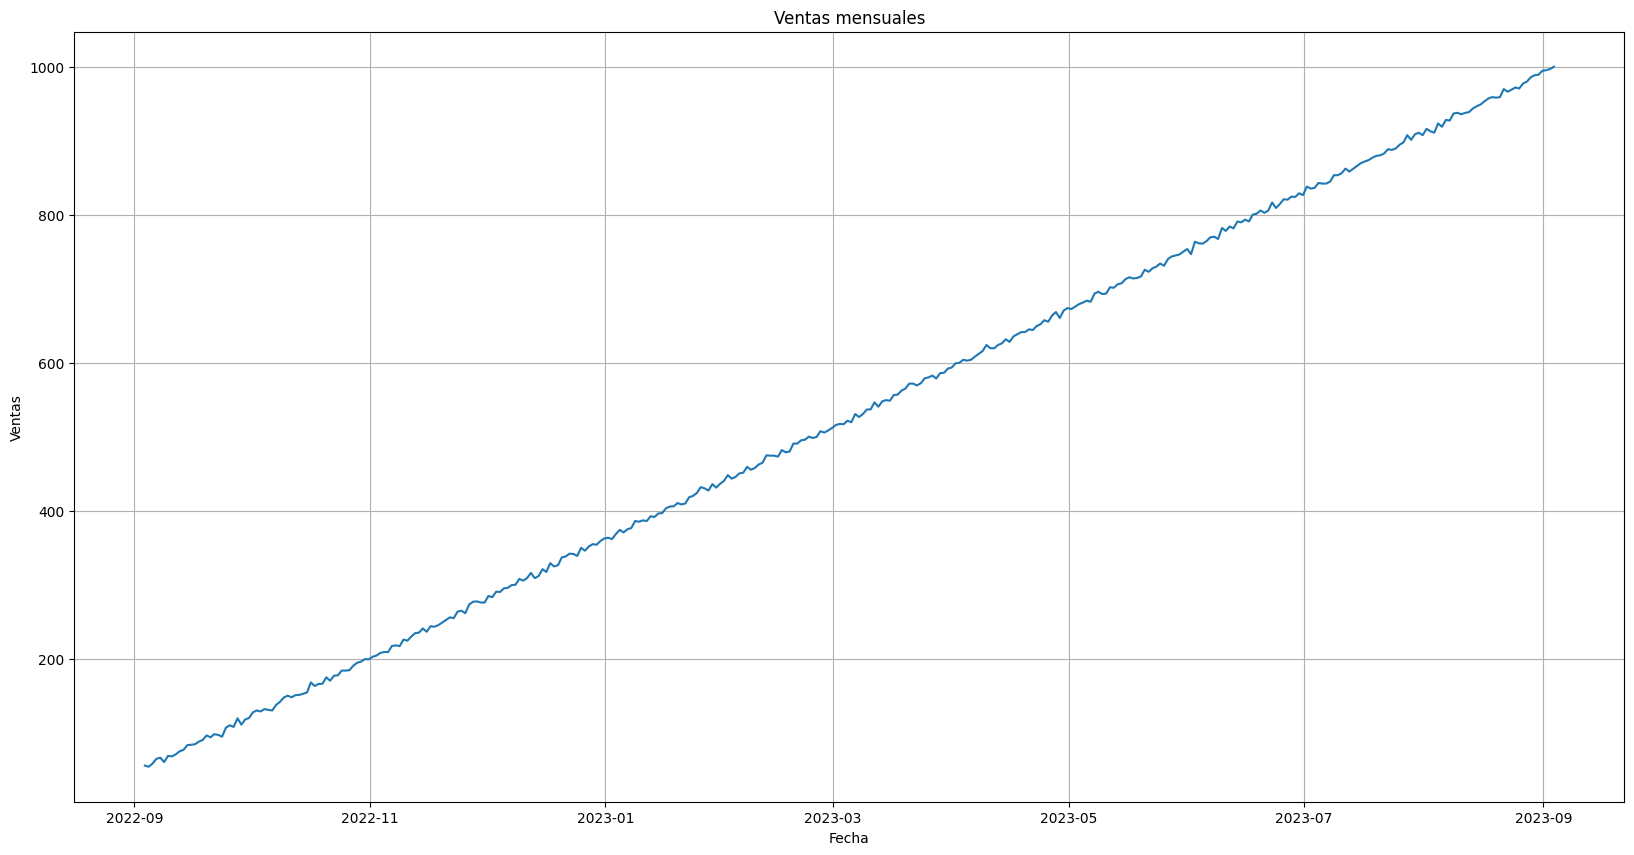

In [45]:
sales['date'] = pd.to_datetime(sales['date'])
sales.set_index('date', inplace=True)


plt.figure(figsize=(20, 10))
plt.plot(sales)
plt.title('Ventas mensuales')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid(True)
plt.show()

### Respuestas a las preguntas del análisis:
**1. ¿Cuál es el tensor de la serie temporal?**
- El tensor es mensual, ya que tenemos un dato por mes.

**2. ¿Cuál es la tendencia?**

- Claramente hay una tendencia ascendente a lo largo del tiempo.

**3. ¿Es estacionaria?**

- Vamos a realizar el test de Dickey-Fuller aumentado para comprobarlo

In [46]:
result = adfuller(sales['sales'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value}')

ADF Statistic: 0.545414193706378
p-value: 0.9861899815311064
Critical Values:
	1%: -3.4490648539347544
	5%: -2.8697861692116478
	10%: -2.5711631253228306


El p-valor es 0.99 > 0.05, por lo que no podemos rechazar la hipótesis nula (la serie no es estacionaria).

**4. ¿Existe variabilidad o presencia de ruido?**

Vamos a descomponer la serie para analizarlo

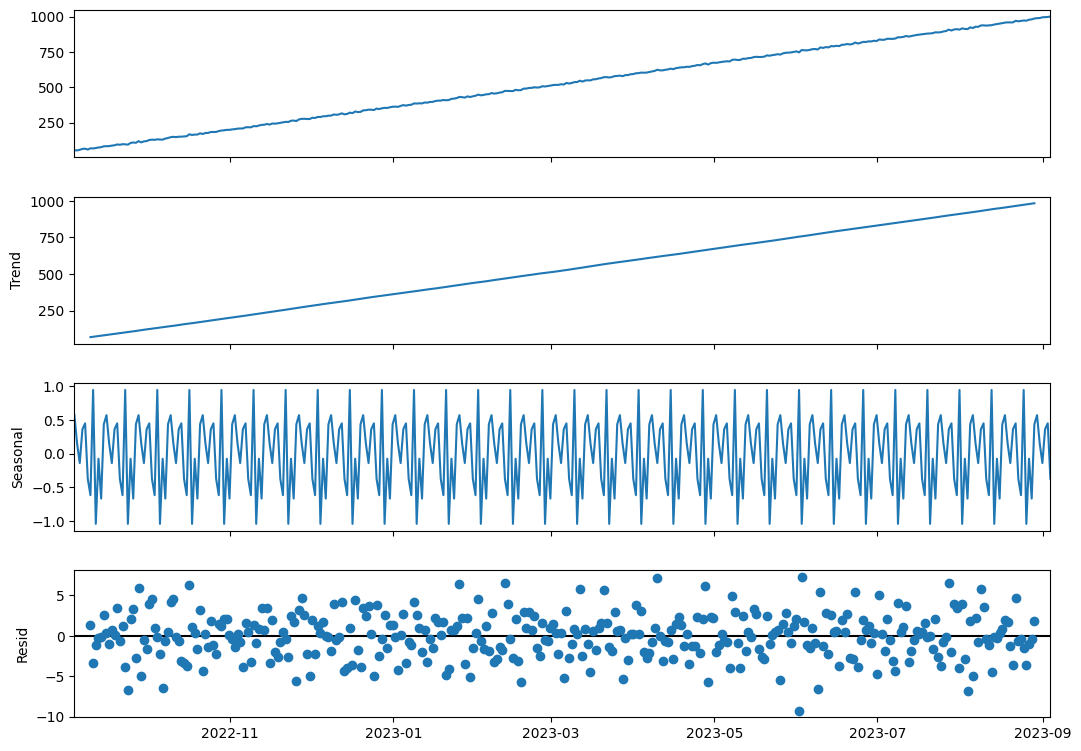

In [47]:
decomposition = seasonal_decompose(sales, model='additive', period=12)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

Podemos observar que:
- Hay una clara tendencia ascendente
- Existe estacionalidad anual (patrón que se repite cada 12 meses)
- El residuo (ruido) parece relativamente constante

### Paso 3: Entrenamiento del modelo ARIMA

Hacemos la serie estacionaria aplicando diferenciación

In [48]:
sales_diff = sales.diff().dropna()

Volvemos a comprobar estacionariedad

In [49]:
result_diff = adfuller(sales_diff['sales'])
print('ADF Statistic (diff):', result_diff[0])
print('p-value (diff):', result_diff[1])

ADF Statistic (diff): -9.430263118334729
p-value (diff): 5.212954111417404e-16


Ahora el p-valor es < 0.05, por lo que la serie diferenciada es estacionaria.

In [50]:
# Dividimos en train y test (usaremos los últimos 12 meses como test)
train = sales[:-12]
test = sales[-12:]

# Entrenamos el modelo ARIMA
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

# Resumen del modelo
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  354
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1019.081
Date:                Thu, 01 May 2025   AIC                           2044.161
Time:                        17:18:47   BIC                           2055.761
Sample:                    09-03-2022   HQIC                          2048.777
                         - 08-22-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.002    593.845      0.000       0.997       1.003
ma.L1         -0.9992      0.689     -1.451      0.147      -2.349       0.351
sigma2        18.5995     12.879      1.444      0.1

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


### Paso 4: Predicción y evaluación del modelo

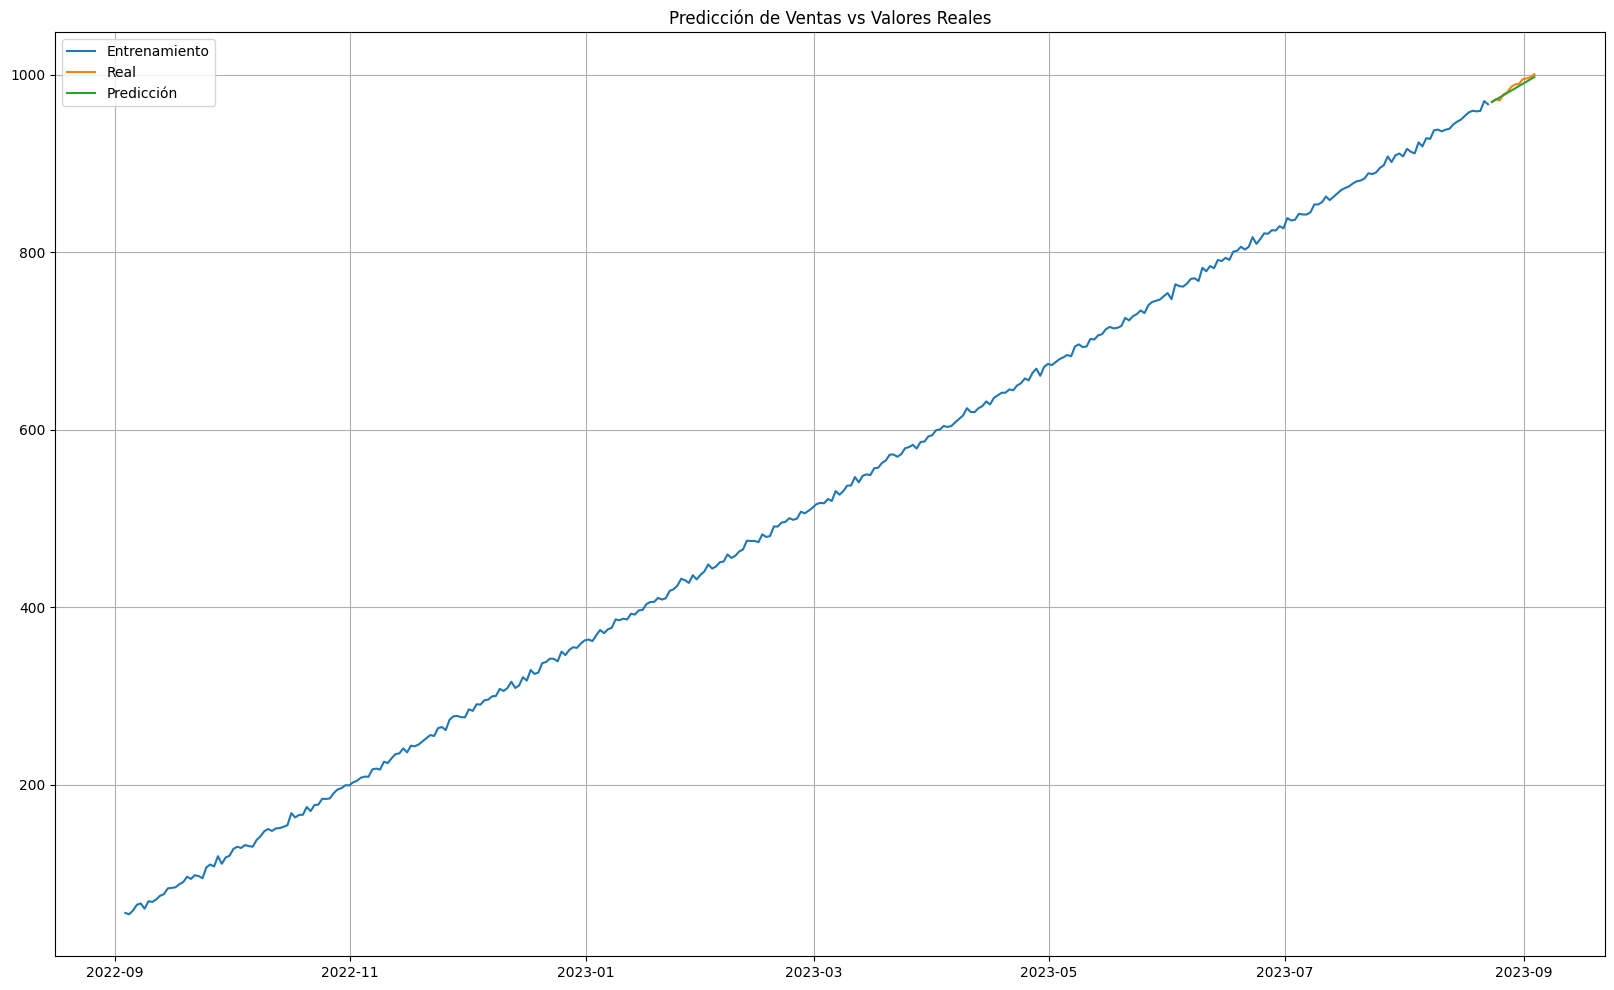

RMSE: 3.0453910957068704


In [51]:
predictions = model_fit.forecast(steps=12)

plt.figure(figsize=(20, 12))
plt.plot(train.index, train, label='Entrenamiento')
plt.plot(test.index, test, label='Real')
plt.plot(test.index, predictions, label='Predicción')
plt.title('Predicción de Ventas vs Valores Reales')
plt.legend()
plt.grid(True)
plt.show()

# Calculamos el error (RMSE)
rmse = np.sqrt(mean_squared_error(test, predictions))
print(f'RMSE: {rmse}')


In [52]:
# Guardamos el modelo entrenado
with open('/workspaces/Proyecto-de-Serie-Temporal-Alternativa/models/arima_chan_model.pkl', 'wb') as f:
    pickle.dump(model_fit, f)

print("Modelo guardado como 'arima_chan_model.pkl'")

Modelo guardado como 'arima_chan_model.pkl'
